In [1]:
import librosa
import matplotlib.pyplot as plt
import numpy as np
import noisereduce as nr
import soundfile as sf
import os
from glob import glob

## Support Function

In [3]:
def clean_and_visualize_noise(real_audio_path, output_clean_path):
    print("🧹 Loading real aphasia recording...")
    y_real, sr = librosa.load(real_audio_path, sr=22050)
    
    # 1. Grab a "Noise Profile"
    # We assume the first 0.5 seconds of the recording is just the patient breathing / mic hiss before they speak.
    # (Adjust these indices if the noise is somewhere else in the file!)
    noise_clip = y_real[int(12.0 * sr):int(13.0 * sr)]
    
    # 2. Apply Spectral Gating (The Cleaning Math)
    print("🧼 Applying Spectral Gating...")
    y_clean = nr.reduce_noise(y=y_real, sr=sr, y_noise=noise_clip, prop_decrease=1.0)
    
    # Save the cleaned audio so you can use it for MCD later
    sf.write(output_clean_path, y_clean, sr)
    
    # 3. Calculate the STFT for Visualization
    # This transforms the 1D waveform into a 2D matrix of Frequencies over Time
    D_noisy = librosa.amplitude_to_db(np.abs(librosa.stft(y_real)), ref=np.max)
    D_clean = librosa.amplitude_to_db(np.abs(librosa.stft(y_clean)), ref=np.max)
    
    # 4. Plot the Thesis Visuals!
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))
    
    librosa.display.specshow(D_noisy, sr=sr, x_axis='time', y_axis='hz', ax=ax[0], cmap='magma')
    ax[0].set_title('Original Noisy STFT', fontsize=14)
    fig.colorbar(ax[0].collections[0], ax=ax[0], format="%+2.0f dB")
    
    librosa.display.specshow(D_clean, sr=sr, x_axis='time', y_axis='hz', ax=ax[1], cmap='magma')
    ax[1].set_title('Cleaned STFT', fontsize=14)
    fig.colorbar(ax[1].collections[0], ax=ax[1], format="%+2.0f dB")
    
    plt.tight_layout()
    plt.show()
    
    return y_clean, sr

def visualize_dtw(y_real_clean, sr, tts_audio_path):
    print("⏱️ Loading TTS audio for time warping...")
    y_tts, _ = librosa.load(tts_audio_path, sr=sr)
    
    # Extract MFCCs (The actual features we use for MCD)
    mfcc_real = librosa.feature.mfcc(y=y_real_clean, sr=sr, n_mfcc=13)
    mfcc_tts = librosa.feature.mfcc(y=y_tts, sr=sr, n_mfcc=13)
    
    # Calculate the Dynamic Time Warping distance and the optimal alignment path
    D, wp = librosa.sequence.dtw(X=mfcc_real, Y=mfcc_tts, metric='euclidean')
    
    # Plot the DTW Path
    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(D, cmap='viridis', origin='lower')
    ax.plot(wp[:, 1], wp[:, 0], color='red', linewidth=3, label='Optimal Warping Path')
    
    ax.set_title('DTW Alignment: Real Speech vs. TTS', fontsize=16)
    ax.set_xlabel('TTS Audio Frames', fontsize=12)
    ax.set_ylabel('Real Aphasic Audio Frames', fontsize=12)
    ax.legend(loc='upper left')
    fig.colorbar(im, ax=ax, label='Euclidean Distance')
    
    plt.show()

## Cleaning & Visualization

🧹 Loading real aphasia recording...
🧼 Applying Spectral Gating...


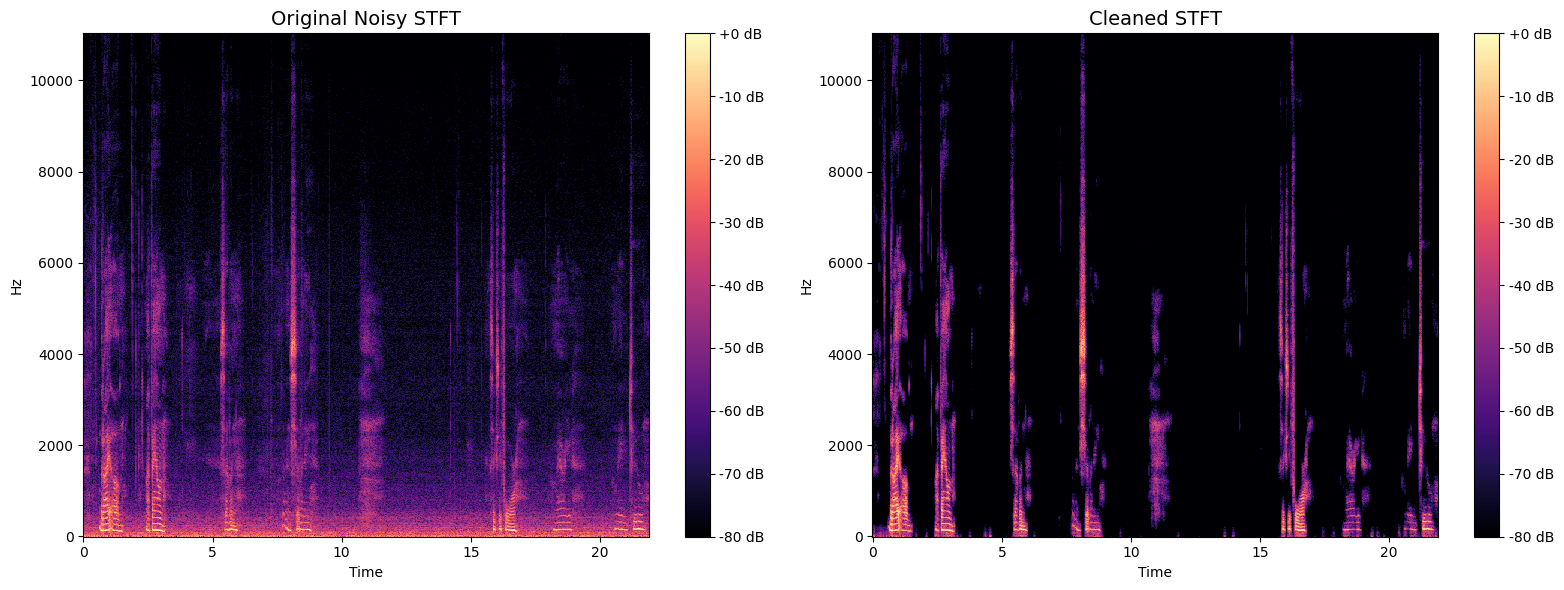

In [4]:
# Point these to your actual files
REAL_AUDIO = "/rds/general/user/ak8224/home/emoji_project/data/Aphasia/final/patient1_0432.wav"
CLEAN_OUTPUT = "cleaned_aphasia_recording.wav"

# 1. Clean the audio and plot the Fourier STFT
y_clean, sr = clean_and_visualize_noise(REAL_AUDIO, CLEAN_OUTPUT)

⏱️ Loading TTS audio for time warping...


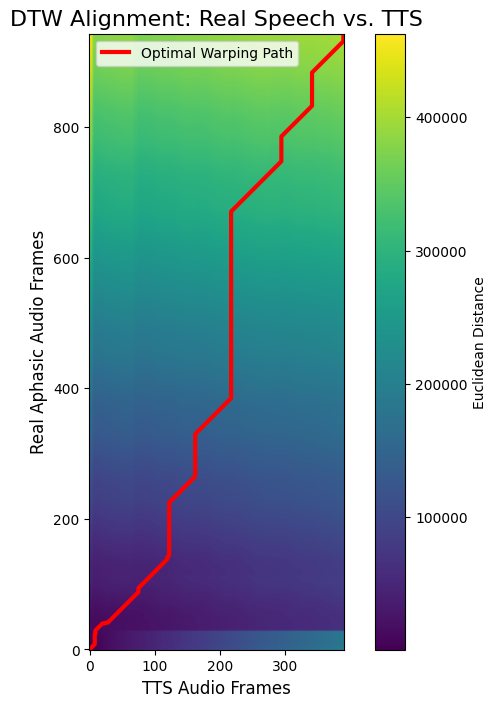

In [6]:
TTS_AUDIO = "/rds/general/user/ak8224/home/emoji_project/data/Aphasia/tts_speech.wav"

# 2. Visualize the DTW Alignment
visualize_dtw(y_clean, sr, TTS_AUDIO)


## DTW Comparison

## Batch Normalization

In [12]:
def batch_clean_folder(reference_audio_path, input_folder, output_folder):
    print(f"🔍 Extracting noise profile from: {reference_audio_path}...")
    
    # 1. Load the reference audio to get the exact mic hiss
    y_ref, sr = librosa.load(reference_audio_path, sr=22050)
    
    # Grab the Noise Profile (Seconds 12.0 to 13.0)
    noise_clip = y_ref[int(12.0 * sr):int(13.0 * sr)]
    
    # 2. Ensure output folder exists
    os.makedirs(output_folder, exist_ok=True)
    
    # 3. Find all .wav files in the input folder
    audio_files = glob(os.path.join(input_folder, "*.wav"))
    print(f"📁 Found {len(audio_files)} files to clean. Starting batch process...\n")
    
    # 4. Loop through and clean every file!
    for file_path in audio_files:
        filename = os.path.basename(file_path)
        out_path = os.path.join(output_folder, filename)
        
        # Load the individual noisy chunk
        y_noisy, _ = librosa.load(file_path, sr=sr)
        
        # Apply Spectral Gating using the shared noise profile
        y_clean = nr.reduce_noise(y=y_noisy, sr=sr, y_noise=noise_clip, prop_decrease=1.0)
        
        # Save the cleaned audio
        sf.write(out_path, y_clean, sr)
        print(f"   ✅ Cleaned and saved: {filename}")
        
    print("\n🎉 Batch cleaning complete! All files are ready for MCD benchmarking.")

In [13]:
# --- EXECUTE THE BATCH SCRIPT ---
# The long audio file where you know 12s-13s is pure noise
REFERENCE_FILE = "/rds/general/user/ak8224/home/emoji_project/data/Aphasia/final/patient1_0432.wav" 

# The folder containing all your chopped up test chunks
INPUT_DIR = "/rds/general/user/ak8224/home/emoji_project/data/Aphasia-Filter/final"

# The folder where the clean versions will go
OUTPUT_DIR = "/rds/general/user/ak8224/home/emoji_project/data/Aphasia-Filter/filtered"

batch_clean_folder(REFERENCE_FILE, INPUT_DIR, OUTPUT_DIR)

🔍 Extracting noise profile from: /rds/general/user/ak8224/home/emoji_project/data/Aphasia/final/patient1_0432.wav...
📁 Found 100 files to clean. Starting batch process...

   ✅ Cleaned and saved: patient1_0496.wav
   ✅ Cleaned and saved: patient1_0342.wav
   ✅ Cleaned and saved: patient1_0331.wav
   ✅ Cleaned and saved: patient1_0405.wav
   ✅ Cleaned and saved: patient1_0082.wav
   ✅ Cleaned and saved: patient1_0233.wav
   ✅ Cleaned and saved: patient1_0432.wav
   ✅ Cleaned and saved: patient1_0250.wav
   ✅ Cleaned and saved: patient1_0312.wav
   ✅ Cleaned and saved: patient1_0001.wav
   ✅ Cleaned and saved: patient1_0245.wav
   ✅ Cleaned and saved: patient1_0478.wav
   ✅ Cleaned and saved: patient1_0390.wav
   ✅ Cleaned and saved: patient1_0266.wav
   ✅ Cleaned and saved: patient1_0391.wav
   ✅ Cleaned and saved: patient1_0513.wav
   ✅ Cleaned and saved: patient1_0145.wav
   ✅ Cleaned and saved: patient1_0122.wav
   ✅ Cleaned and saved: patient1_0499.wav
   ✅ Cleaned and saved: patien

## Voice Activity Detector (VAD) & Pause-to-Speech Ratio 

In [ ]:
def analyze_single_vad(audio_path, top_db=15):
    # 1. Instant Loading with soundfile
    y, sr = sf.read(audio_path)
    
    # Convert stereo to mono if necessary
    if y.ndim > 1:
        y = y.mean(axis=1)
        
    total_duration = len(y) / sr
    
    # 2. Run the VAD with your optimal 15dB threshold
    speech_intervals = librosa.effects.split(y, top_db=top_db)
    speech_samples = sum([end - start for start, end in speech_intervals])
    
    speech_duration = speech_samples / sr
    pause_duration = total_duration - speech_duration
    
    # 3. Calculate metrics
    speech_ratio = speech_duration / total_duration if total_duration > 0 else 0
    pause_ratio = pause_duration / total_duration if total_duration > 0 else 0
    
    # 🚨 THE FIX: We must RETURN this dictionary so the batch loop can aggregate it!
    return {
        "filename": os.path.basename(audio_path),
        "total_sec": total_duration,
        "speech_sec": speech_duration,
        "pause_sec": pause_duration,
        "speech_ratio": float(f"{speech_ratio:.4f}"),
        "pause_ratio": float(f"{pause_ratio:.4f}")
    }

def batch_analyze_directory_vad(directory_path):
    audio_files = glob(os.path.join(directory_path, "*.wav"))
    
    if not audio_files:
        print(f"❌ No .wav files found in {directory_path}")
        return
        
    print(f"🔍 Analyzing {len(audio_files)} files in directory: {directory_path}\n")
    
    total_dataset_duration = 0.0
    total_dataset_speech = 0.0
    total_dataset_pause = 0.0
    
    # Process each file and print individual stats
    for file_path in audio_files:
        stats = analyze_single_vad(file_path)
        
        # Aggregate global metrics
        total_dataset_duration += stats["total_sec"]
        total_dataset_speech += stats["speech_sec"]
        total_dataset_pause += stats["pause_sec"]
        
        print(f"📄 {stats['filename']}:")
        print(f"   Duration: {stats['total_sec']:.2f}s | Speech: {stats['speech_ratio']:.4f} | Pause: {stats['pause_ratio']:.4f}")
    
    # Calculate Global Ratios
    global_speech_ratio = total_dataset_speech / total_dataset_duration
    global_pause_ratio = total_dataset_pause / total_dataset_duration
    
    print("\n" + "="*50)
    print("📊 GLOBAL DATASET VAD BASELINE")
    print("="*50)
    print(f"Total Audio Processed : {total_dataset_duration / 60:.2f} minutes")
    print(f"Global Speech Ratio   : {global_speech_ratio:.4f}")
    print(f"Global Pause Ratio    : {global_pause_ratio:.4f}")
    print("="*50)

In [10]:
REFERENCE_FILE = "/rds/general/user/ak8224/home/emoji_project/data/Aphasia/final/patient1_0432.wav" 

# Run the batch analyzer
analyze_single_vad(REFERENCE_FILE)

Total Audio Duration: 21.9020 seconds

Testing top_db=15:
   Speech: 7.8019s | Pause: 14.1001s
   Speech Ratio: 0.3562 | Pause Ratio: 0.6438



In [13]:
TARGET_DIRECTORY = "/rds/general/user/ak8224/home/emoji_project/data/Aphasia-Filter/filtered"
batch_analyze_directory_vad(TARGET_DIRECTORY)

🔍 Analyzing 100 files in directory: /rds/general/user/ak8224/home/emoji_project/data/Aphasia-Filter/filtered

Total Audio Duration: 1.1240 seconds

Testing top_db=15:
   Speech: 0.9847s | Pause: 0.1393s
   Speech Ratio: 0.8760 | Pause Ratio: 0.1240



TypeError: 'NoneType' object is not subscriptable

## Calculate MCD

In [7]:
import numpy as np

def calculate_mcd(y_real_clean, y_tts, sr):
    print("🧮 Extracting MFCCs...")
    # Extract 13 MFCCs
    mfcc_real = librosa.feature.mfcc(y=y_real_clean, sr=sr, n_mfcc=13)
    mfcc_tts = librosa.feature.mfcc(y=y_tts, sr=sr, n_mfcc=13)
    
    # 🚨 Crucial Step: Drop the 0th coefficient (energy/volume)
    # We only care about the phonetic pronunciation, not if one file is louder!
    mfcc_real = mfcc_real[1:, :]
    mfcc_tts = mfcc_tts[1:, :]
    
    print("⏱️ Running Dynamic Time Warping...")
    # Run DTW to get the alignment path
    D, wp = librosa.sequence.dtw(X=mfcc_real, Y=mfcc_tts, metric='euclidean')
    
    # librosa's wp returns the path from end-to-start, so we reverse it
    wp = wp[::-1] 
    
    # Separate the coordinates for the real audio and TTS audio
    path_real = wp[:, 0]
    path_tts = wp[:, 1]
    
    print("📏 Calculating Frame-by-Frame Distortion...")
    # Create new matrices where the frames are perfectly aligned side-by-side
    aligned_mfcc_real = mfcc_real[:, path_real]
    aligned_mfcc_tts = mfcc_tts[:, path_tts]
    
    # Subtract the matrices to find the difference
    diff = aligned_mfcc_real - aligned_mfcc_tts
    
    # Calculate Euclidean distance for each aligned frame
    frame_distances = np.sqrt(np.sum(diff ** 2, axis=0))
    
    # The MCD Constant (10 * sqrt(2) / ln(10))
    K = 10.0 / np.log(10.0) * np.sqrt(2.0)
    
    # Average the distances and convert to dB
    mcd_score = K * np.mean(frame_distances)
    
    print(f"✅ Final MCD Score: {mcd_score:.4f} dB")
    return mcd_score

In [10]:
# --- EXECUTE SCORE ---
# Run this using your cleaned audio and the TTS audio!
y_real, _ = librosa.load(REAL_AUDIO, sr=sr)
y_tts, _ = librosa.load(TTS_AUDIO, sr=sr)
mcd_result = calculate_mcd(y_real, y_tts, sr)

🧮 Extracting MFCCs...
⏱️ Running Dynamic Time Warping...
📏 Calculating Frame-by-Frame Distortion...
✅ Final MCD Score: 252.3485 dB
